In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd

df = pd.read_csv("titanic_df.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:

df = pd.read_csv("titanic_df.csv")

display(df.describe())

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
def perform_eda(df):
    print("Shape of the DataFrame:")
    display(df.shape)

    print("\nInformation about the DataFrame:")
    df.info()

    print("\nDescriptive statistics of the DataFrame:")
    display(df.describe())


# correct call
perform_eda(df)

Shape of the DataFrame:


(891, 12)


Information about the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Descriptive statistics of the DataFrame:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
missing_values = df.isnull().sum()

missing_percentage = (missing_values / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage': missing_percentage
})

display(missing_info)

,Missing Values,Missing Percentage
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
Age,177,19.865320
SibSp,0,0.000000
Parch,0,0.000000
Ticket,0,0.000000
Fare,0,0.000000


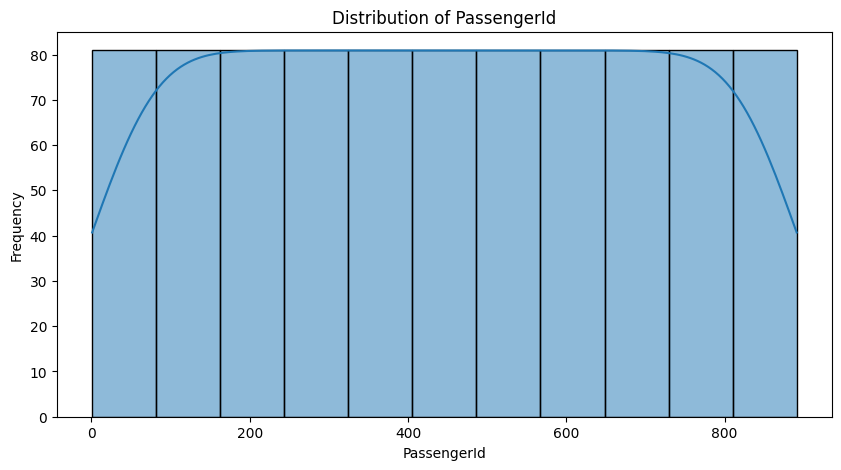

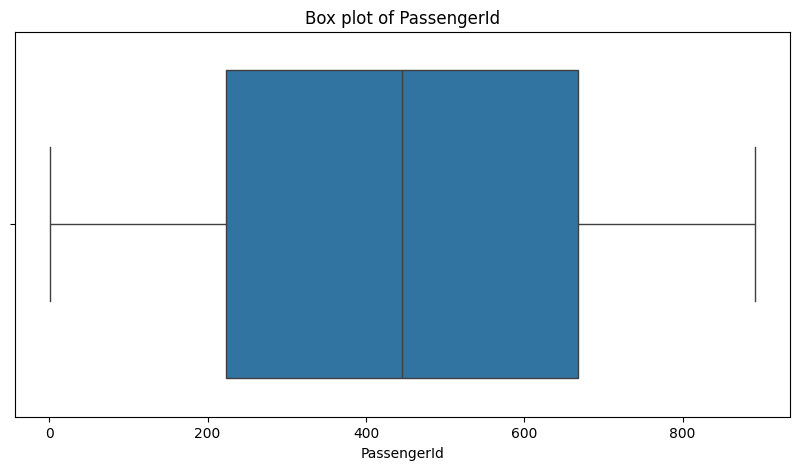

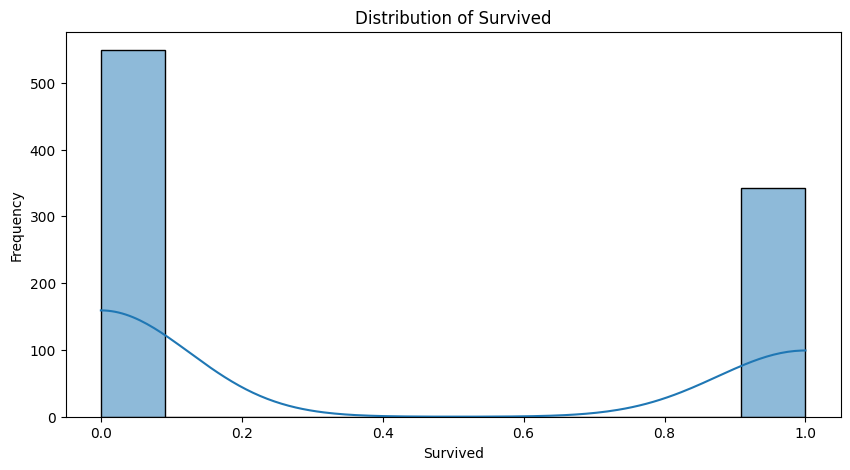

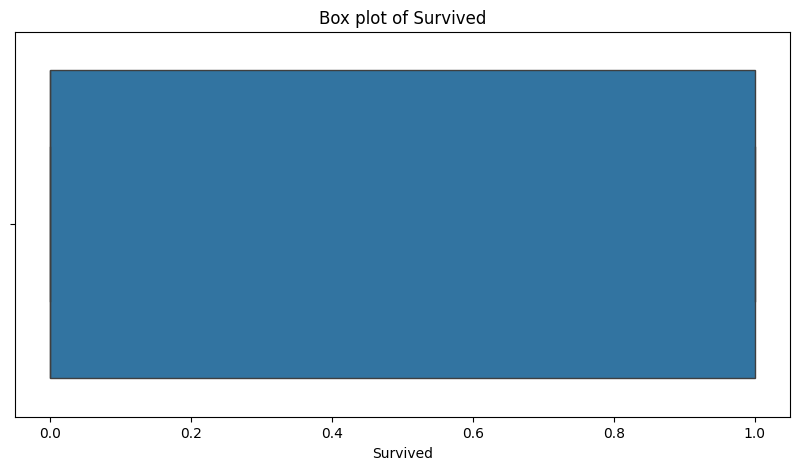

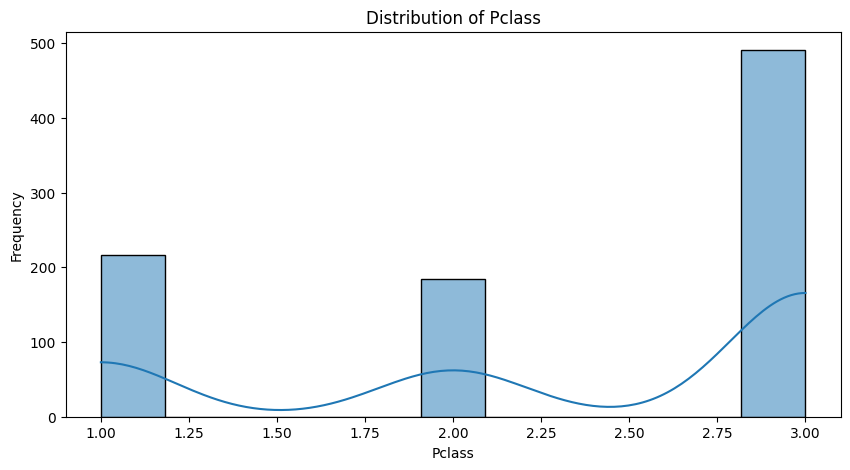

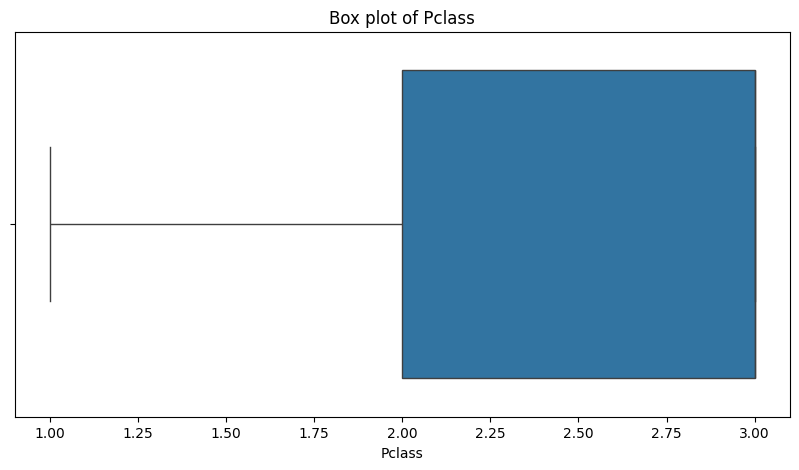

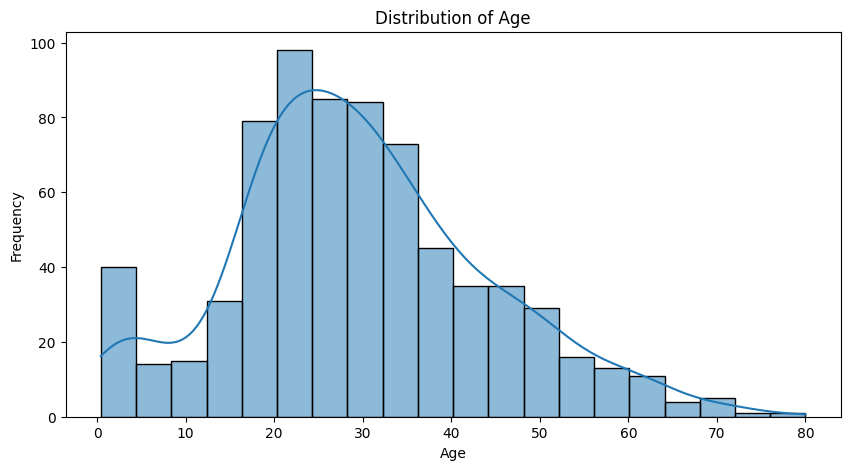

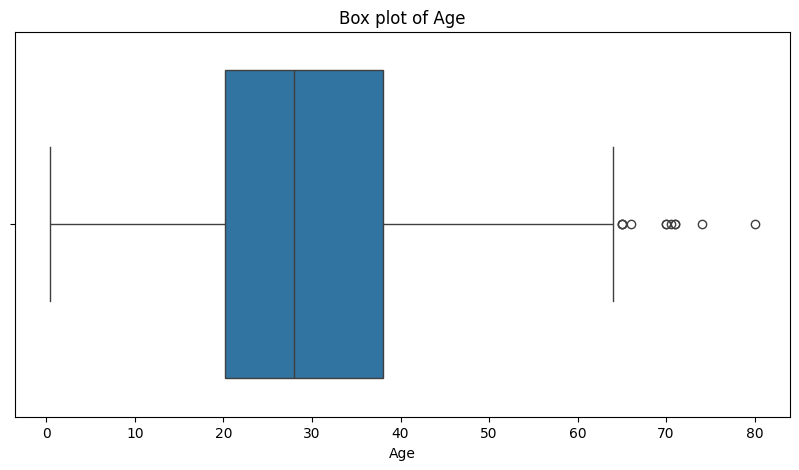

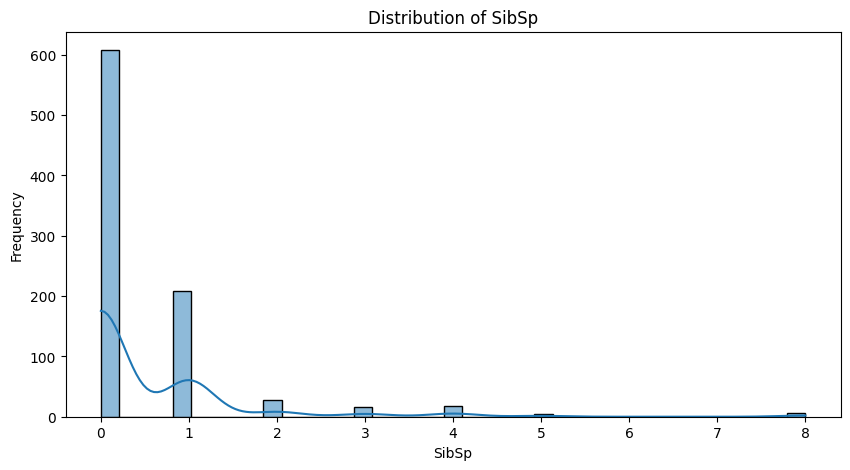

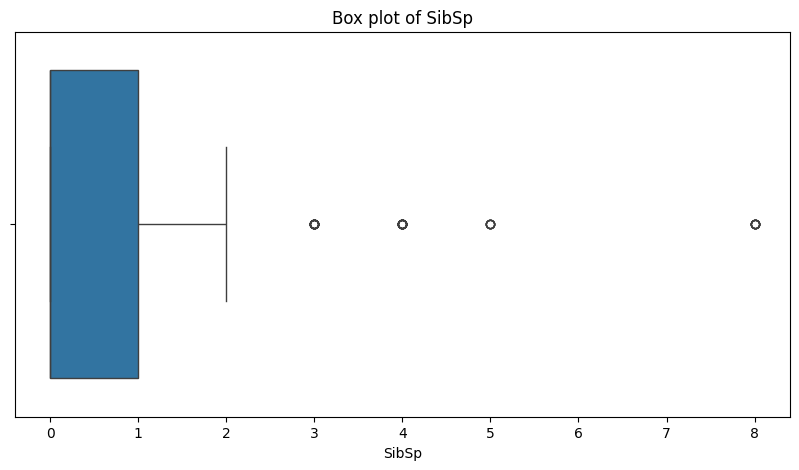

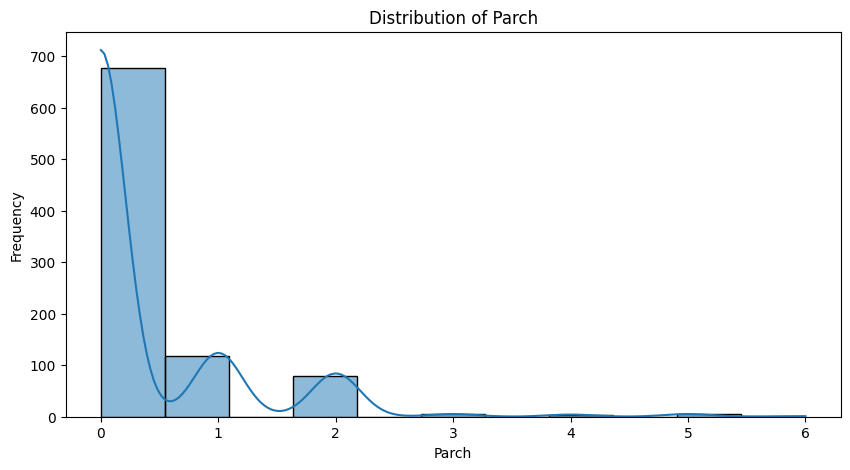

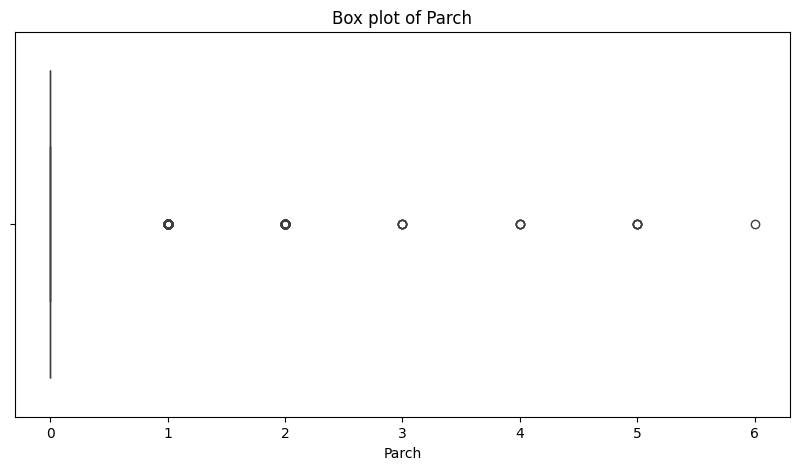

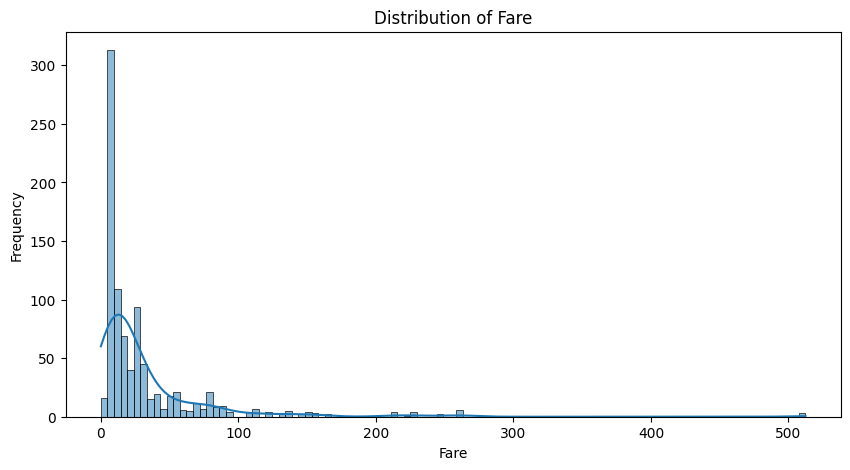

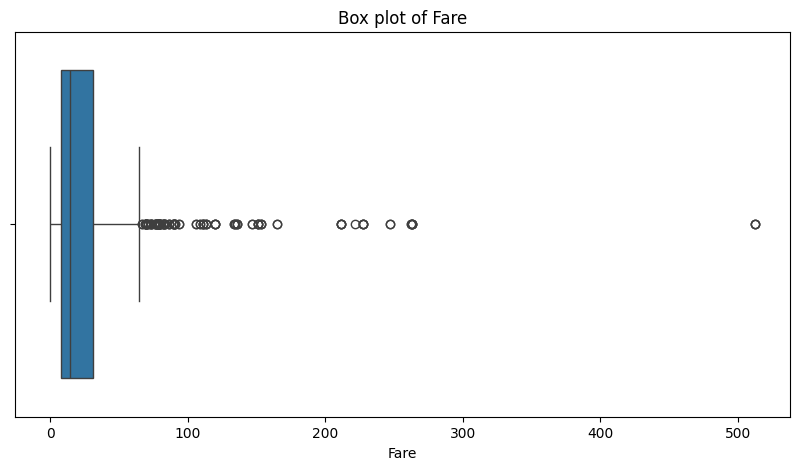

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = df.select_dtypes(include=['number']).columns

for col in numerical_cols:
    plt.figure(figsize=(10, 5))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x=col)
    plt.title(f'Box plot of {col}')
    plt.xlabel(col)
    plt.show()

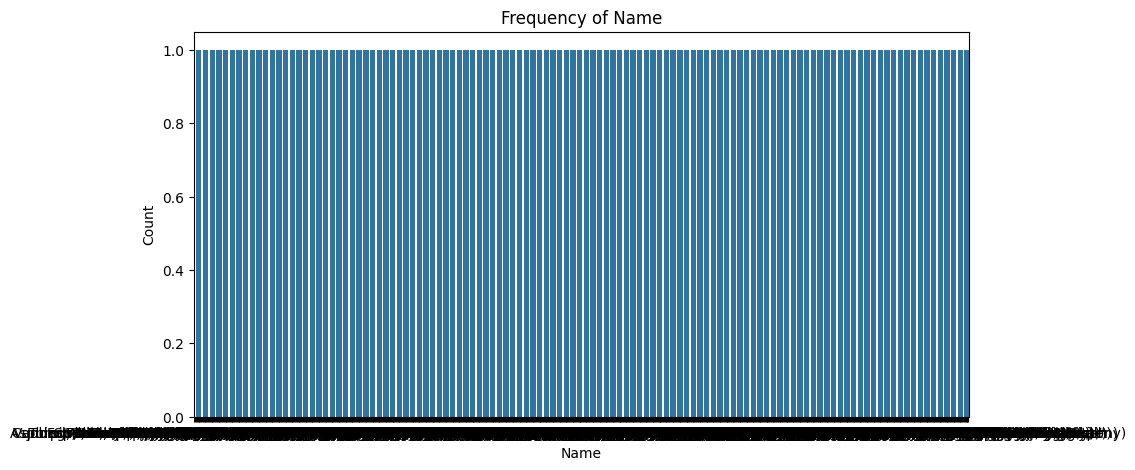

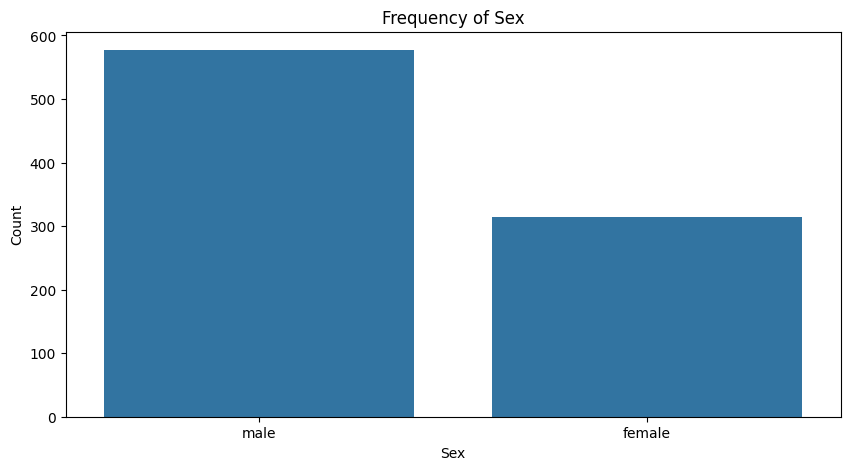

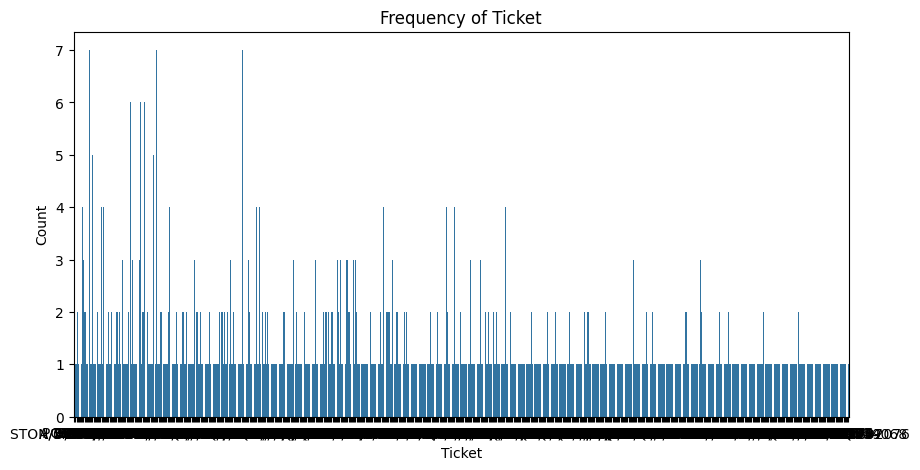

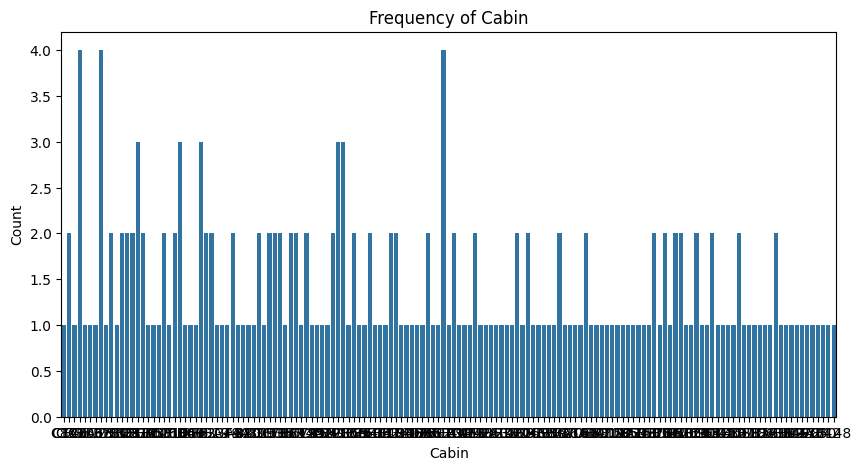

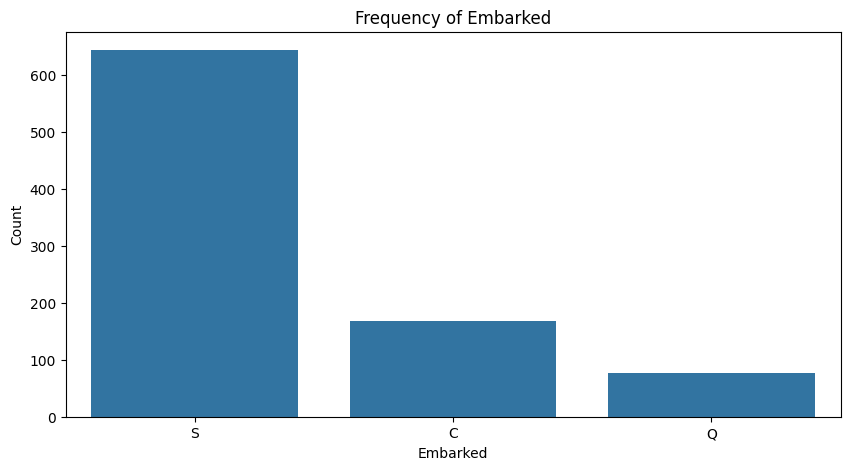

In [ ]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=col)
    plt.title(f'Frequency of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

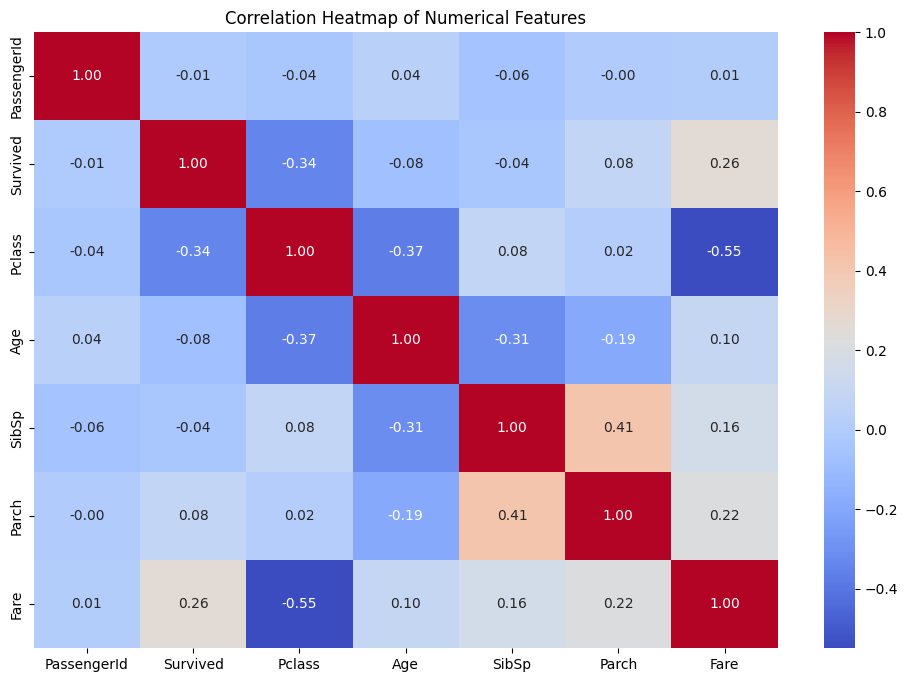

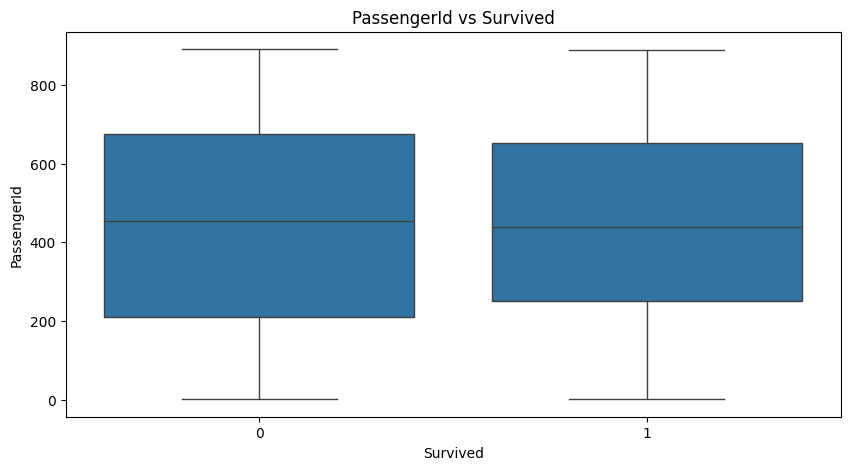

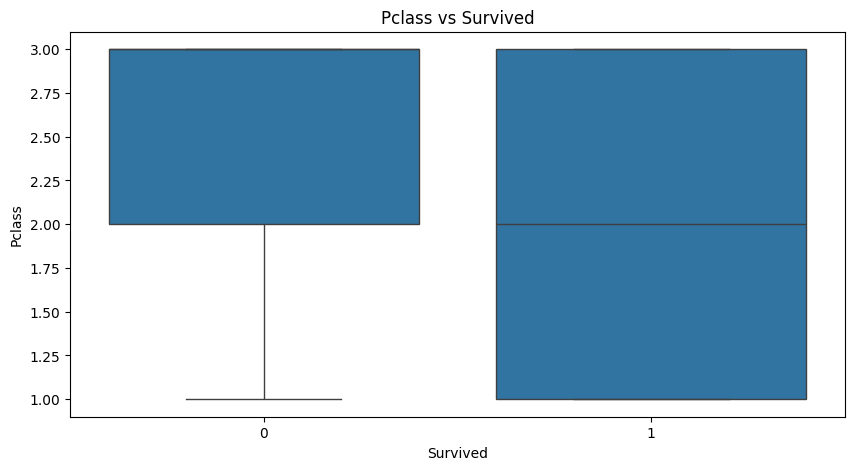

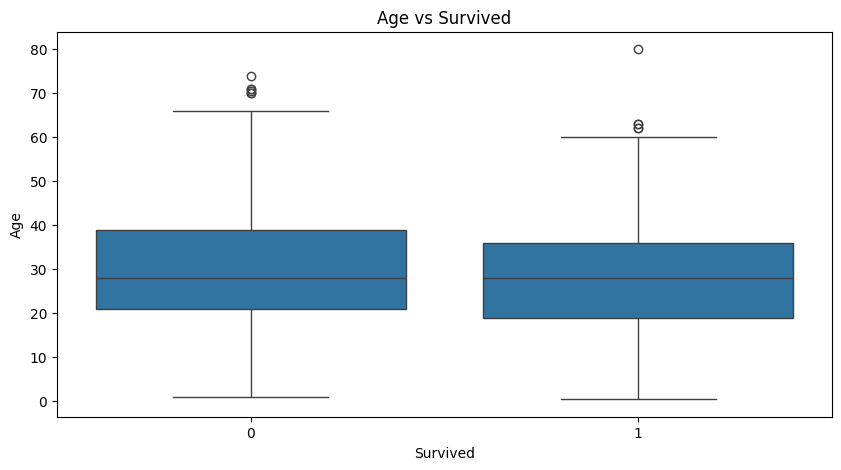

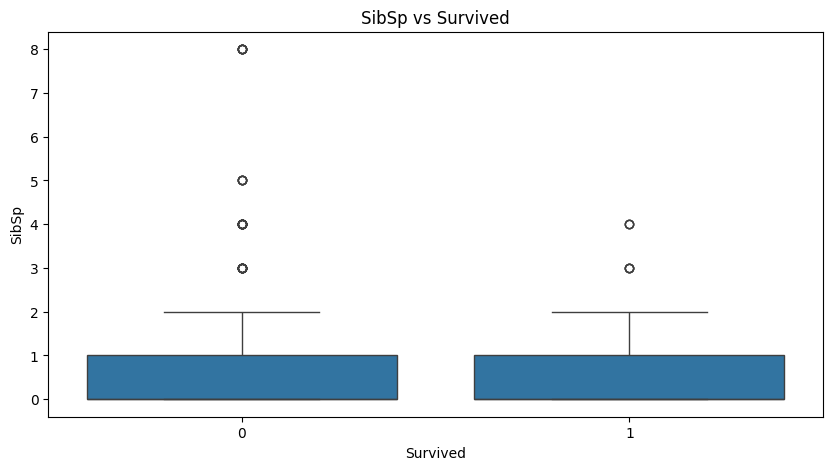

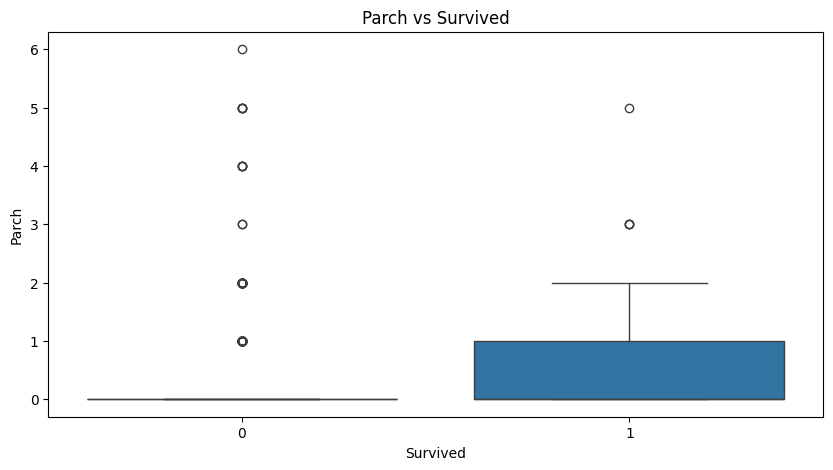

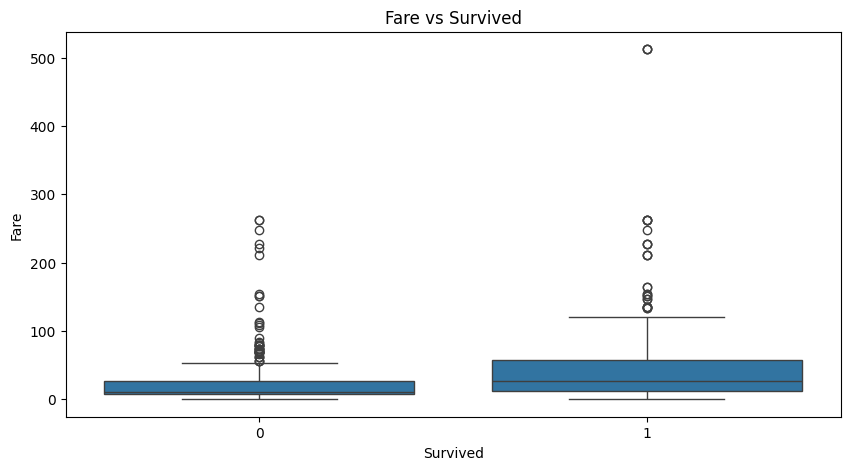

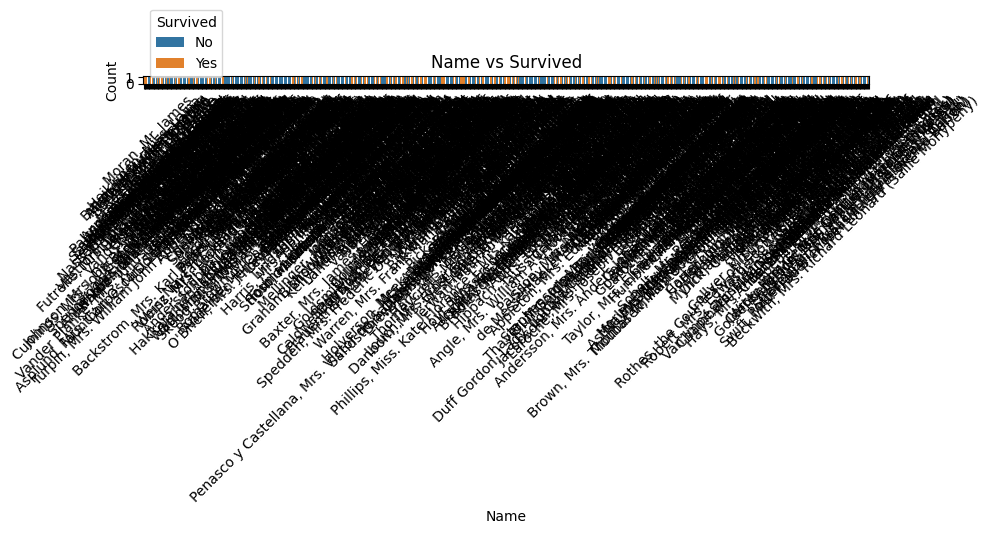

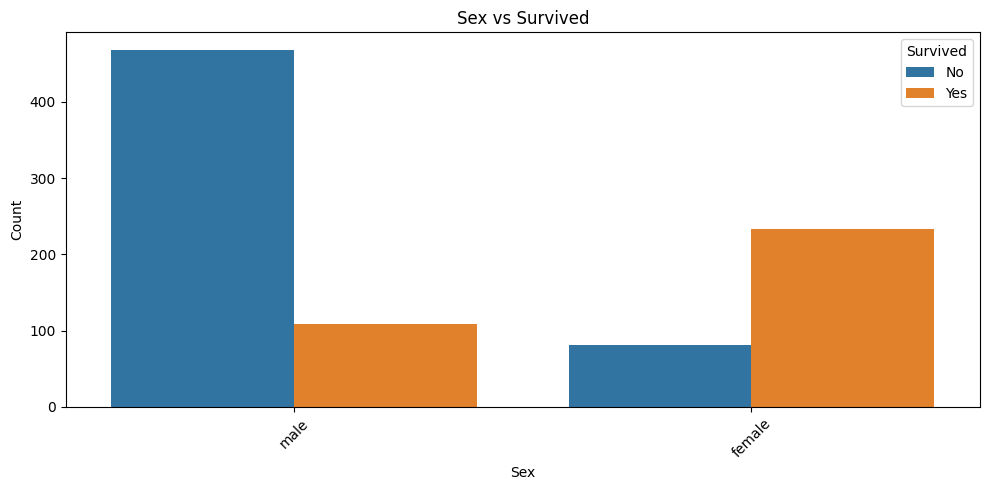

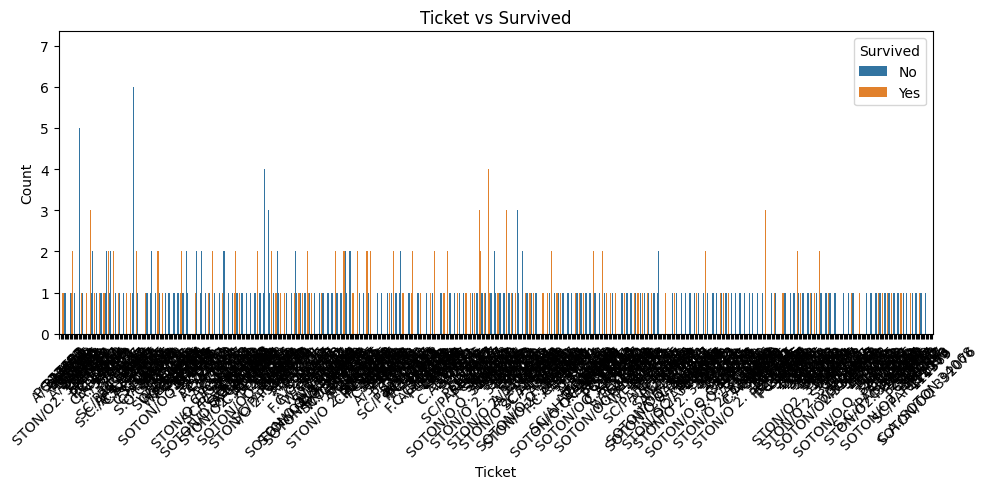

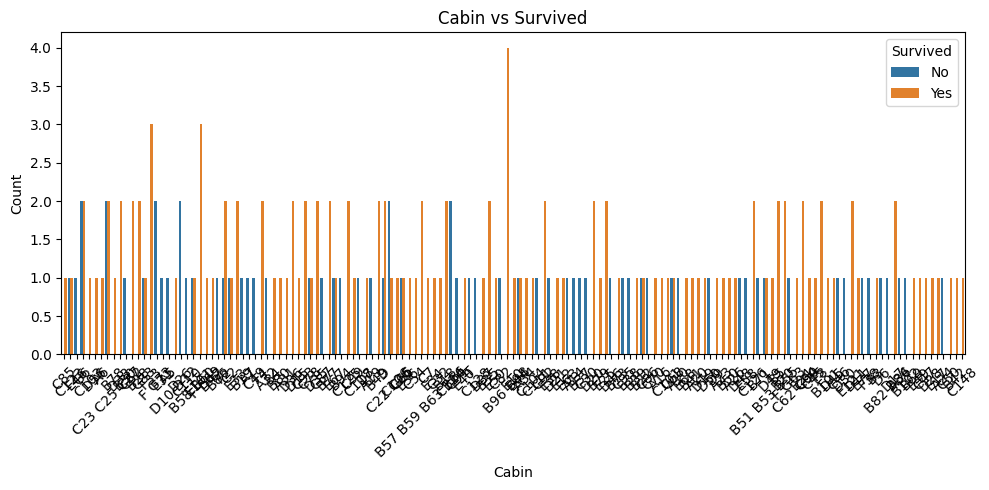

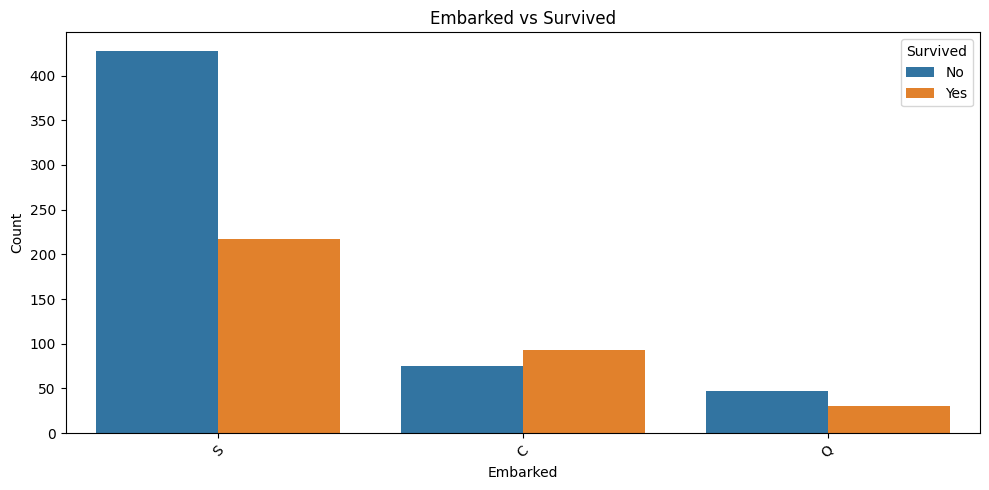

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# numerical columns
numerical_cols = df.select_dtypes(include=['number']).columns

# correlation heatmap
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# numerical vs survived
for col in numerical_cols:
    if col != 'Survived':
        plt.figure(figsize=(10, 5))
        sns.boxplot(data=df, x='Survived', y=col)
        plt.title(f'{col} vs Survived')
        plt.xlabel('Survived')
        plt.ylabel(col)
        plt.show()

# categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

# categorical vs survived
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=col, hue='Survived')
    plt.title(f'{col} vs Survived')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.legend(title='Survived', labels=['No', 'Yes'])
    plt.tight_layout()
    plt.show()

In [ ]:
perform_eda(df)

Shape of the DataFrame:


(891, 12)


Information about the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Descriptive statistics of the DataFrame:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# Fill missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop columns safely
df.drop(columns=['Cabin', 'Ticket', 'Name', 'PassengerId'], 
        inplace=True, errors='ignore')

print(df.isnull().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [ ]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Is alone
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# Age groups
df['AgeBand'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100],
                       labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior'])

# Fare groups
df['FareBand'] = pd.qcut(df['Fare'], q=4,
                         labels=['Low', 'Medium', 'High', 'VeryHigh'],
                         duplicates='drop')

In [ ]:
df.drop(['SibSp', 'Parch'], axis=1, inplace=True)


In [ ]:
print(df.columns)

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize',
       'IsAlone', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'AgeBand_Teen',
       'AgeBand_YoungAdult', 'AgeBand_Adult', 'AgeBand_Senior',
       'FareBand_Medium', 'FareBand_High', 'FareBand_VeryHigh'],
      dtype='object')


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features & target
X = df.drop(columns=['Survived'])
y = df['Survived']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



In [ ]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# imports
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42)
}
results = {}

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score
for name, model in models.items():

    if name in ['Logistic Regression', 'SVM']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results[name] = {'Accuracy': acc, 'ROC-AUC': roc}

    print(f"{name:25s} | Accuracy: {acc*100:.2f}% | ROC-AUC: {roc:.4f}")

Logistic Regression       | Accuracy: 81.01% | ROC-AUC: 0.8563
Decision Tree             | Accuracy: 76.54% | ROC-AUC: 0.8062
Random Forest             | Accuracy: 79.33% | ROC-AUC: 0.8194
Gradient Boosting         | Accuracy: 81.01% | ROC-AUC: 0.8176
SVM                       | Accuracy: 83.24% | ROC-AUC: 0.8520


In [ ]:
results_df = pd.DataFrame(results).T
print("\nFinal Results:")
print(results_df.sort_values(by='ROC-AUC', ascending=False))


Final Results:
                     Accuracy   ROC-AUC
Logistic Regression  0.810056  0.856258
SVM                  0.832402  0.852042
Random Forest        0.793296  0.819368
Gradient Boosting    0.810056  0.817589
Decision Tree        0.765363  0.806192


In [ ]:
best_model = results_df['ROC-AUC'].idxmax()
print("\nBest Model:", best_model)


Best Model: Logistic Regression


In [ ]:
results_sorted = sorted(results.items(), key=lambda x: x[1]['ROC-AUC'], reverse=True)

model_names = [x[0] for x in results_sorted]
accuracies  = [x[1]['Accuracy'] * 100 for x in results_sorted]
roc_aucs    = [x[1]['ROC-AUC'] for x in results_sorted]

In [ ]:
results = {}

for name, model in models.items():

    if name in ['Logistic Regression', 'SVM']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results[name] = {
        'Accuracy': acc,
        'ROC-AUC': roc,
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob
    }

In [ ]:
best_model_name = max(results, key=lambda m: results[m]['ROC-AUC'])
best_result = results[best_model_name]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [ ]:
print(best_result.keys())

dict_keys(['Accuracy', 'ROC-AUC', 'model', 'y_pred', 'y_prob'])


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    best_result['y_pred'],
    target_names=['Not Survived', 'Survived']
))

              precision    recall  f1-score   support

Not Survived       0.82      0.88      0.85       110
    Survived       0.79      0.70      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179



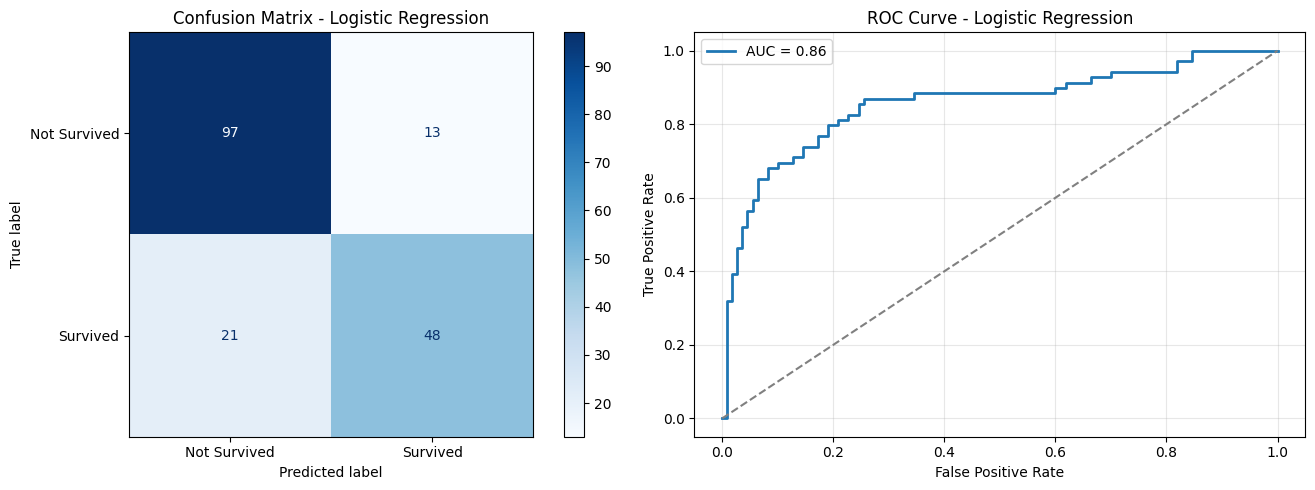

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve
import matplotlib.pyplot as plt

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# =========================
# Confusion Matrix
# =========================
cm = confusion_matrix(y_test, best_result['y_pred'])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Survived', 'Survived']
)

disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f'Confusion Matrix - {best_model_name}')

# =========================
# ROC Curve
# =========================
fpr, tpr, _ = roc_curve(y_test, best_result['y_prob'])

axes[1].plot(fpr, tpr, lw=2,
             label=f'AUC = {best_result["ROC-AUC"]:.2f}')

# Random classifier line
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')

axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC Curve - {best_model_name}')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

C:\Users\KIMS\AppData\Local\Temp\ipykernel_7080\1087447836.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


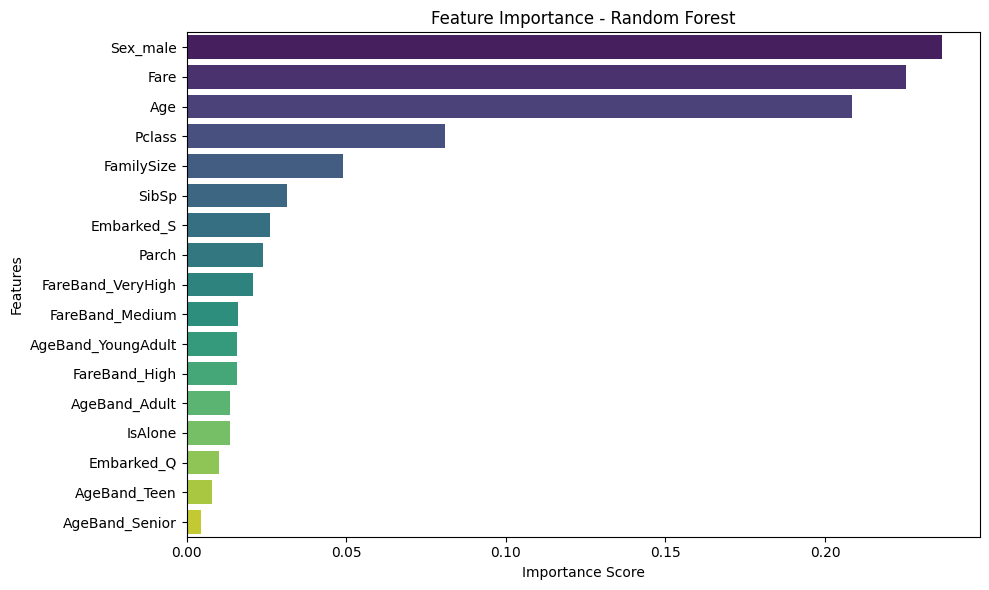


Top Features:
Sex_male              0.236734
Fare                  0.225295
Age                   0.208419
Pclass                0.080815
FamilySize            0.049075
SibSp                 0.031486
Embarked_S            0.026267
Parch                 0.024012
FareBand_VeryHigh     0.020829
FareBand_Medium       0.015966
AgeBand_YoungAdult    0.015790
FareBand_High         0.015739
AgeBand_Adult         0.013612
IsAlone               0.013474
Embarked_Q            0.010019
AgeBand_Teen          0.007960
AgeBand_Senior        0.004507
dtype: float64


In [ ]:
# Get Random Forest model
rf_model = results['Random Forest']['model']

# Create feature importance series
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Plot Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(
    x=feature_importance.values,
    y=feature_importance.index,
    palette='viridis'
)

plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Print all features
print("\nTop Features:")
print(feature_importance)

C:\Users\KIMS\AppData\Local\Temp\ipykernel_7080\1642764089.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


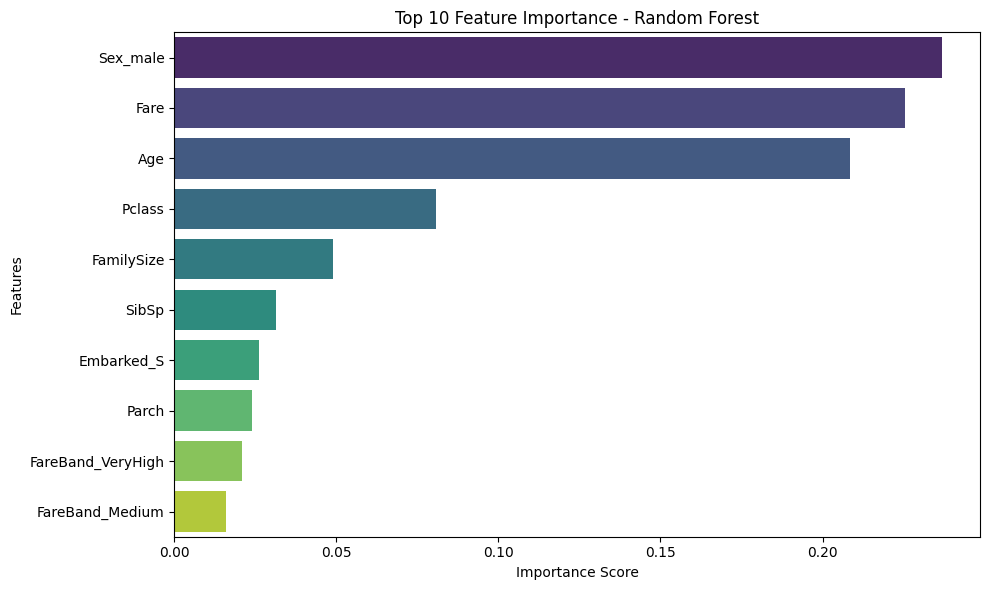

In [ ]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_features.values,
    y=top_features.index,
    palette='viridis'
)

plt.title('Top 10 Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

print("5-Fold Cross-Validation Scores:\n")

for name, res in results.items():

    model = res['model']

    # Use scaled data for LR and SVM
    if name in ['Logistic Regression', 'SVM']:
        X_used = scaler.transform(X)
    else:
        X_used = X

    cv_scores = cross_val_score(
        model,
        X_used,
        y,
        cv=5,
        scoring='accuracy'
    )

    print(f"{name:25s} | Mean: {cv_scores.mean()*100:.2f}% | Std: {cv_scores.std()*100:.2f}%")

5-Fold Cross-Validation Scores:

Logistic Regression       | Mean: 79.91% | Std: 1.95%
Decision Tree             | Mean: 81.37% | Std: 1.99%
Random Forest             | Mean: 80.14% | Std: 3.66%
Gradient Boosting         | Mean: 81.71% | Std: 2.70%
SVM                       | Mean: 82.27% | Std: 1.58%


In [ ]:
best_model = results['SVM']['model']
best_model.fit(X, y)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [ ]:
import pandas as pd

# Create new passenger (use SAME columns as training data)
new_passenger = pd.DataFrame({
    'Pclass': [1],
    'Age': [25],
    'Fare': [72],
    'FamilySize': [1],
    'IsAlone': [1],

    # Encoded columns (IMPORTANT)
    'Sex_male': [0],          # female = 0
    'Embarked_S': [1],        # S = 1
    'Embarked_Q': [0],        # not Q

    'AgeBand_Teen': [0],
    'AgeBand_YoungAdult': [1],
    'AgeBand_Adult': [0],
    'AgeBand_Senior': [0],

    'FareBand_Medium': [0],
    'FareBand_High': [0],
    'FareBand_VeryHigh': [1],
})

# Ensure column order same as training data
new_passenger = new_passenger.reindex(columns=X.columns, fill_value=0)

# Get best model
best_model = results[best_model_name]['model']

# Prediction
if best_model_name in ['Logistic Regression', 'SVM']:
    new_scaled = scaler.transform(new_passenger)
    pred = best_model.predict(new_scaled)[0]
    prob = best_model.predict_proba(new_scaled)[0][1]
else:
    pred = best_model.predict(new_passenger)[0]
    prob = best_model.predict_proba(new_passenger)[0][1]

# Output
status = 'SURVIVED ✅' if pred == 1 else 'NOT SURVIVED ❌'

print(f"Prediction: {status}")
print(f"Survival Probability: {prob*100:.1f}%")

Prediction: SURVIVED ✅
Survival Probability: 93.7%


In [ ]:
# Save cleaned dataset
df.to_csv("titanic_cleaned.csv", index=False)

# Save model
import joblib
joblib.dump(best_model, "titanic_model.pkl")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

print("All files saved successfully!")

All files saved successfully!
